In [1]:
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np

from mdx2.io import loadobj


# Scaling model

Visualize the mdx2 scaling model.

## Parameters

In [2]:
# These metadata fields are injected by mdx2.report, regardless of the template. Don't change this line.
_metadata: dict = {}

# Notebook parameters
scaling_model_sources: list[str] = []  # ScalingModel source encoded as a string nexus_file_path:object_name
offset_model_sources: list[str] = []  # OffsetModel sources encoded as a string nexus_file_path:object_name
absorption_model_sources: list[str] = []  # AbsorptionModel sources encoded as a string nexus_file_path:object_name
detector_model_sources: list[str] = []  # DetectorModel sources encoded as a string nexus_file_path:object_name

In [3]:
# Parameters
scaling_model_sources = ["../scales.nxs:scaling_model"]
_metadata = {"author": "Steve Meisburger", "date_created": "2026-04-17 13:35:09", "mdx2_version": "1.0.3", "environment": "cbsuando2.biohpc.cornell.edu", "working_directory": "/local/storage/steve/mdx2_dev/examples/insulin-tutorial/reports", "notebook_template": "scaling_model"}


In [4]:
# pretty-print the metadata and parameters
pprint({
    "metadata": _metadata,
    "parameters": {"scaling_model_sources": scaling_model_sources,
                   "offset_model_sources": offset_model_sources,
                   "absorption_model_sources": absorption_model_sources,
                   "detector_model_sources": detector_model_sources,
    },
})

{'metadata': {'author': 'Steve Meisburger',
              'date_created': '2026-04-17 13:35:09',
              'environment': 'cbsuando2.biohpc.cornell.edu',
              'mdx2_version': '1.0.3',
              'notebook_template': 'scaling_model',
              'working_directory': '/local/storage/steve/mdx2_dev/examples/insulin-tutorial/reports'},
 'parameters': {'absorption_model_sources': [],
                'detector_model_sources': [],
                'offset_model_sources': [],
                'scaling_model_sources': ['../scales.nxs:scaling_model']}}


## Results

### Scale

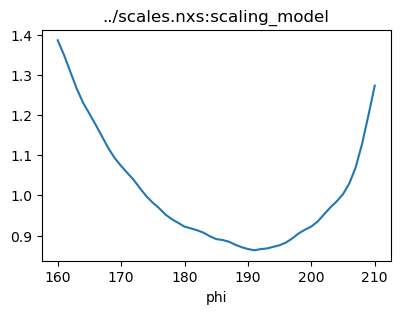

In [5]:
for scaling_model_source in scaling_model_sources or []:
    try:
        scaling_model = loadobj(*scaling_model_source.split(":"))
    except Exception as e:
        print(f"failed to load {scaling_model_source}: {e}")
        continue
    b = scaling_model.to_xarray()
    b.plot(aspect=1.5, size=3)
    plt.title(f"{scaling_model_source}")

### Offset

In [6]:
for offset_model_source in offset_model_sources or []:
    try:
        offset_model = loadobj(*offset_model_source.split(":"))
    except Exception as e:
        print(f"failed to load {offset_model_source}: {e}")
        continue
    c = offset_model.to_xarray()
    c.plot(aspect=1.5, size=3)
    plt.title(f"{offset_model_source}")

### Absorption

In [7]:
for absorption_model_source in absorption_model_sources or []:
    try:
        absorption_model = loadobj(*absorption_model_source.split(":"))
    except Exception as e:
        print(f"failed to load {absorption_model_source}: {e}")
        continue
    a = absorption_model.to_xarray()
    phi_min = a.phi[0].data
    phi_max = a.phi[-1].data
    phi_interval = 360/8
    npts = int(1 + (phi_max - phi_min) / phi_interval)
    col_wrap = min(8, npts)
    a_sliced = a.sel(phi=np.linspace(phi_min, phi_max, npts),method='nearest')
    g = a_sliced.plot(
        yincrease=False,
        x='ix',
        y='iy',
        col='phi',
        cmap='coolwarm',
        robust=True,
        col_wrap=col_wrap,
        size=1.5,
        )
    for ax in g.axs.flatten():
        ax.set_aspect('equal')
    plt.title(f"{absorption_model_source}")

### Detector

In [8]:
unique_detector_models = []
for detector_model_source in detector_model_sources or []:
    try:
        detector_model = loadobj(*detector_model_source.split(":"))
    except Exception as e:
        print(f"failed to load {detector_model_source}: {e}")
        continue
    # first, check if this detector model is identical to any of the previously loaded ones
    if any(np.array_equal(detector_model.u, d.u) for d in unique_detector_models):
        print(f"skipping duplicate detector model {detector_model_source}")
        continue
    unique_detector_models.append(detector_model)
    d = detector_model.to_xarray()
    d.plot(x='ix', y='iy', yincrease=False,cmap='coolwarm', robust=True, size=6)
    plt.title(f"{detector_model_source}")
